# Workshop 02

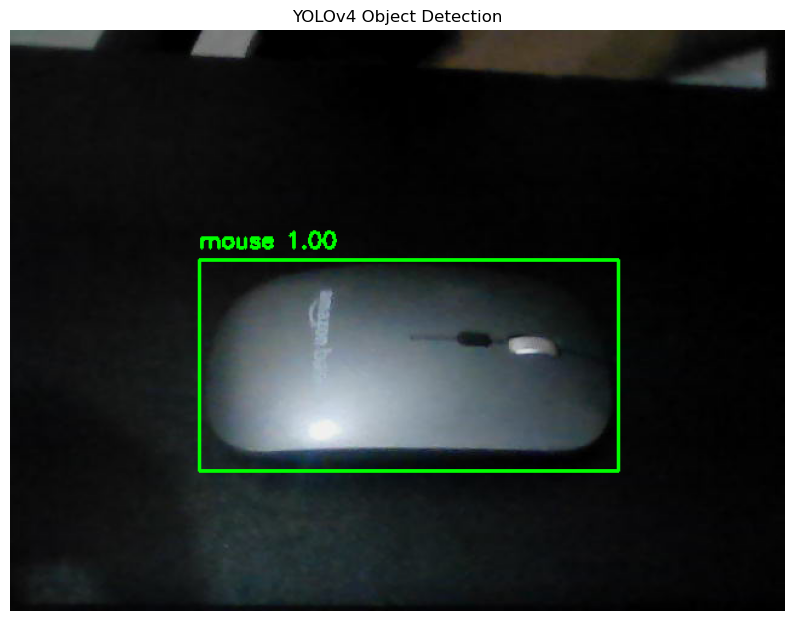

In [11]:
## DEVELOP BY RAJA GOPAL V
## REG NO : 212223240134


import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load YOLOv4
net = cv2.dnn.readNet("yolov4.weights", "yolov4.cfg")

# Load COCO class names
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# Get output layers
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

# Open webcam
cap = cv2.VideoCapture(0)

ret, frame = cap.read()

cap.release()

if not ret:
    print("Failed to capture image from webcam")

else:

    height, width = frame.shape[:2]

    # Create blob
    blob = cv2.dnn.blobFromImage(
        frame,
        1 / 255.0,
        (416, 416),
        swapRB=True,
        crop=False
    )

    net.setInput(blob)

    # Forward pass
    outputs = net.forward(output_layers)

    boxes = []
    confidences = []
    class_ids = []

    # Process detections
    for output in outputs:
        for detection in output:

            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]

            if confidence > 0.5:

                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)

                w = int(detection[2] * width)
                h = int(detection[3] * height)

                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Non-Maximum Suppression
    indexes = cv2.dnn.NMSBoxes(
        boxes,
        confidences,
        0.5,
        0.4
    )

    # Draw boxes
    if len(indexes) > 0:

        for i in indexes.flatten():

            x, y, w, h = boxes[i]

            label = classes[class_ids[i]]
            confidence = confidences[i]

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            cv2.putText(
                frame,
                f"{label} {confidence:.2f}",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    # Display result in Jupyter Output Cell
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("YOLOv4 Object Detection")
    plt.show()